In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from portfolio_optimizer.optimizer import StaticOptimizer
from portfolio_optimizer.constraints import create_style_constraints
from portfolio_optimizer.utils import nearest_psd, port_perf

plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# 1. Generate Realistic Mock Data 

print("Generating Mock Market Data...")
assets_list = ['Equity_A [G]', 'Equity_B [G]', 'Property [G]', 'Bonds [D]', 'Cash [D]']
growth_assets = ['Equity_A [G]', 'Equity_B [G]', 'Property [G]']

rf_annual = 0.02 # 2% Risk-free rate

# Mock Annualised Expected Returns (mu)
mu1 = pd.Series([0.10, 0.08, 0.09, 0.04, 0.02], index=assets_list)
vols = np.array([0.15, 0.12, 0.18, 0.05, 0.01])

# Mock Correlation Matrix (All positively correlated except cash)
corr_mock = np.array([
    [ 1.00,  0.75,  0.60,  0.10, 0.01],
    [ 0.75,  1.00,  0.50,  0.15, 0.02],
    [ 0.60,  0.50,  1.00,  0.20, 0.01],
    [ 0.10,  0.15,  0.20,  1.00, 0.05],
    [ 0.01,  0.02,  0.01,  0.05, 1.00]
])

# Create valid Positive Semi-Definite Covariance Matrix (Sigma)
D = np.diag(vols)
Sigma1 = D @ corr_mock @ D

def is_psd(A, tol=1e-12):
    eig = np.linalg.eigvalsh((A + A.T)/2)
    return bool(np.all(eig >= -tol)), float(eig.min())

Generating Mock Market Data...


In [3]:
# 2. The Stress Test: Inducing a Correlation Shock

# Pick two growth assets that normally move together
ia, ib = assets_list.index('Equity_A [G]'), assets_list.index('Property [G]')

# Extract correlation, shock it to -0.90, reconstruct covariance
d = np.sqrt(np.diag(Sigma1))
Dinv = np.diag(1.0 / np.where(d>0, d, 1.0))
Corr_broken = Dinv @ Sigma1 @ Dinv

Corr_broken[ia, ib] = -0.90
Corr_broken[ib, ia] = -0.90

Sigma_broken = np.diag(d) @ Corr_broken @ np.diag(d)

ok0, min_eig0 = is_psd(Sigma1)
okb, min_eigb = is_psd(Sigma_broken)

print(f"Baseline Σ PSD Valid? {ok0} | min eigenvalue = {min_eig0:.2e}")
print(f"Shocked  Σ PSD Valid? {okb} | min eigenvalue = {min_eigb:.2e}   <-- Mathematical Failure")

# Fix the broken covariance using our toolkit!
Sigma_fixed = nearest_psd(Sigma_broken)
okf, min_eigf = is_psd(Sigma_fixed)
print(f"Repaired Σ PSD Valid? {okf} | min eigenvalue = {min_eigf:.2e}")

Baseline Σ PSD Valid? True | min eigenvalue = 9.97e-05
Shocked  Σ PSD Valid? False | min eigenvalue = -9.80e-03   <-- Mathematical Failure
Repaired Σ PSD Valid? True | min eigenvalue = 1.00e-12


In [4]:
# 3. Optimization Engine: Original vs Repaired

opt_orig = StaticOptimizer(mu1.values, Sigma1)
opt_fixed = StaticOptimizer(mu1.values, Sigma_fixed)

bounds = tuple((0.0, 0.40) for _ in range(len(assets_list)))
style_cons = create_style_constraints(assets_list, growth_assets, 0.65, 0.75)
target_ret = 0.0582

w_tr_orig = np.clip(opt_orig.target_return(target_ret, bounds, style_cons).x, 0, 1)
w_tr_fixed = np.clip(opt_fixed.target_return(target_ret, bounds, style_cons).x, 0, 1)

def get_stats(w, S, name):
    r, v = port_perf(w, mu1.values, S)
    return {"Scenario": name, "Return": r, "Volatility": v, "Sharpe": (r-rf_annual)/(v+1e-12)}

stats = [get_stats(w_tr_orig, Sigma1, "Original Matrix (Valid)"), 
         get_stats(w_tr_fixed, Sigma_fixed, "Repaired Matrix (Illusion)")]

perf_df = pd.DataFrame(stats).set_index("Scenario")

print("\nPerformance Comparison (Target Return Portfolio)")
print("Notice the fake improvement in Volatility and Sharpe Ratio in the repaired matrix!")
display(perf_df.style.format({'Return': '{:.2%}', 'Volatility': '{:.2%}', 'Sharpe': '{:.4f}'}))


Performance Comparison (Target Return Portfolio)
Notice the fake improvement in Volatility and Sharpe Ratio in the repaired matrix!


,Return,Volatility,Sharpe
Scenario,,,
Original Matrix (Valid),6.28%,7.82%,0.5474
Repaired Matrix (Illusion),6.90%,4.43%,1.1066



=== Weights Shift ===


,Original Allocation,Fragile Allocation (Exploiting Shock)
Equity_A [G],13.21%,35.18%
Equity_B [G],40.00%,0.00%
Property [G],11.79%,29.82%
Bonds [D],0.00%,0.00%
Cash [D],35.00%,35.00%


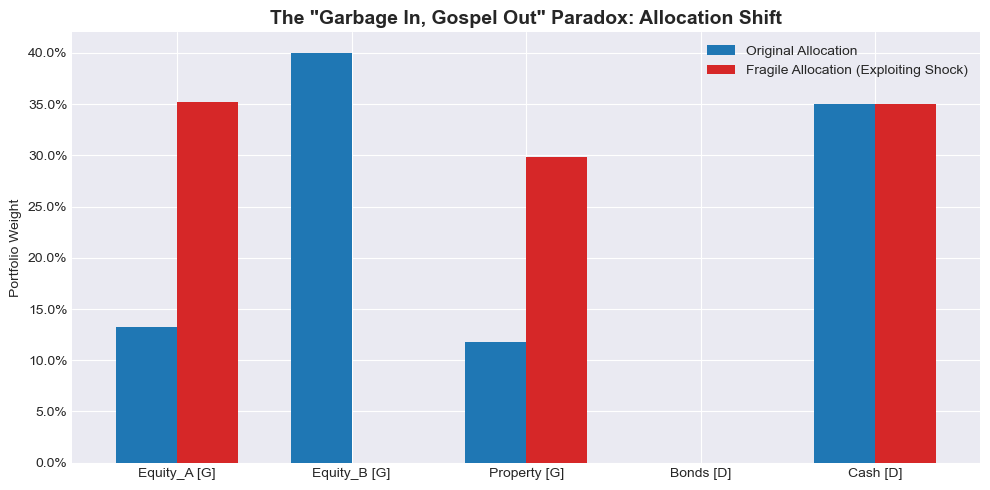

In [5]:
# 4. Visualize the "Garbage In, Gospel Out" Effect
weights_df = pd.DataFrame({
    'Original Allocation': w_tr_orig,
    'Fragile Allocation (Exploiting Shock)': w_tr_fixed
}, index=assets_list)

print("\n=== Weights Shift ===")
display(weights_df.style.format('{:.2%}'))

weights_df.plot(kind='bar', figsize=(10, 5), color=['tab:blue', 'tab:red'], width=0.7)
plt.title('The "Garbage In, Gospel Out" Paradox: Allocation Shift', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Weight')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()